# Approche B : LSTM pour prediction de violations SLA (simu5G)

**Objectif** : Predire si le SLA d'un slice 5G sera viole dans les 15 prochaines secondes,
a partir de metriques issues de la simulation simu5G (OMNeT++ / Simu5G).

**Dataset** : `all_simu5g.csv` (69 511 lignes, 9 scenarios, 4 slices)

**Modele** : LSTM (Long Short-Term Memory) avec fenetre de 30 secondes

**Strategie** : Modele global entraine sur les 4 slices avec split stratifie
pour garantir des violations dans le train pour chaque slice. Les donnees proviennent
de 9 simulations independantes (Normal, Overload, Transition, RealTraffic) combinant
differents niveaux de charge et de stress par slice.

**Ameliorations vs version precedente** :
- `Slice_Packet_Loss_pct` conserve comme feature (24 valeurs uniques, max 1.95%)
- Split stratifie (slice + label) au lieu de split purement temporel
- 24 features : 5 metriques + 15 derivees temporelles + 4 one-hot slices

## 1. Installation des dependances

In [1]:
import subprocess, sys
subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q',
                       'torch', 'scikit-learn', 'matplotlib', 'seaborn'])

0

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import (
    classification_report, confusion_matrix, f1_score,
    roc_auc_score, roc_curve, precision_recall_curve
)
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

print(f'PyTorch : {torch.__version__}')
print(f'Device  : {device}')
print(f'NumPy   : {np.__version__}')
print(f'Pandas  : {pd.__version__}')

PyTorch : 2.10.0+cpu
Device  : cpu
NumPy   : 2.4.1
Pandas  : 3.0.0


## 2. Chargement et exploration des donnees

In [3]:
import os

# Detecter l'environnement (Docker ou local Windows)
if os.path.exists('/home/work/simu5g/output/all_simu5g.csv'):
    csv_path = '/home/work/simu5g/output/all_simu5g.csv'
else:
    csv_path = os.path.join(os.path.dirname(os.path.abspath('.')),
                            'simu5g', 'output', 'all_simu5g.csv')
    if not os.path.exists(csv_path):
        csv_path = r'C:\Users\Utilisateur\Desktop\PFE_BigData\PFE_Bigdata\PFE-NetworkSlicing\PFE-NetworkSlicing\work\simu5g\output\all_simu5g.csv'

print(f'Fichier : {csv_path}')
assert os.path.exists(csv_path), f'Fichier introuvable : {csv_path}'

df = pd.read_csv(csv_path)
print(f'Shape brut : {df.shape}')

# Retirer Best Effort (pas de SLA significatif)
df = df[df['Slice Type'] != 'Best Effort'].reset_index(drop=True)
print(f'Shape sans Best Effort : {df.shape}')
print(f'Slices : {sorted(df["Slice Type"].unique())}')
print(f'Scenarios : {sorted(df["Scenario"].unique())}')
df.head()

Fichier : C:\Users\Utilisateur\Desktop\PFE_BigData\PFE_Bigdata\PFE-NetworkSlicing\PFE-NetworkSlicing\work\simu5g\output\all_simu5g.csv
Shape brut : (95805, 14)
Shape sans Best Effort : (68797, 14)
Slices : ['URLLC', 'eMBB', 'mMTC']
Scenarios : ['CongestionHigh', 'ExtremeLoad', 'HeavyEmbb', 'MediumLoad', 'Normal', 'OverloadAll', 'OverloadEmbb', 'OverloadUrllc', 'RealTraffic', 'RealTrafficOverload', 'StressEmbb', 'TransitionEmbb', 'TransitionUrllc']


,Time_Sec,Slice Type,Scenario,Slice_Throughput_Mbps,Slice_Jitter_ms,Slice_Packet_Loss_pct,Slice_Network_Load_pct,Slice_Latency_ms,SLA_Throughput_Min_Mbps,SLA_PacketLoss_Max_pct,SLA_Latency_Max_ms,SLA_OK,SLA_OK_in_15s,SLA_Violated_in_15s
0,2024-01-01T00:00:00Z,URLLC,CongestionHigh,1.516064,0.0,0.0,30.32128,18.293743,0.5,0.001,20.0,True,False,1
1,2024-01-01T00:00:00Z,URLLC,ExtremeLoad,2.679392,0.0,0.0,53.58784,25.261693,0.5,0.001,20.0,False,False,1
2,2024-01-01T00:00:00Z,URLLC,HeavyEmbb,0.324704,0.0,0.0,6.49408,19.110696,0.5,0.001,20.0,False,False,1
3,2024-01-01T00:00:00Z,URLLC,MediumLoad,0.630720,0.0,0.0,12.61440,14.349659,0.5,0.001,20.0,True,True,0
4,2024-01-01T00:00:00Z,URLLC,Normal,0.270976,0.0,0.0,5.41952,14.314174,0.5,0.001,20.0,False,False,1


In [4]:
# --- Labels SLA originaux (15s lookahead, seuils de l'extraction) ---
# On utilise directement les labels calcules pendant l'extraction (extract_simu5g_metrics.py).
# Pas de recalcul de seuils dans le notebook : les seuils sont definis une seule fois
# dans le script d'extraction pour eviter les incoherences.
#
# La generalisation est assuree par le split leave-one-scenario-out,
# pas par la manipulation des features ou des seuils.

# Convertir Time_Sec en datetime
df['Time_Sec'] = pd.to_datetime(df['Time_Sec'])
df = df.sort_values(['Scenario', 'Slice Type', 'Time_Sec']).reset_index(drop=True)

print('=== Distribution des violations par slice (labels originaux, horizon 15s) ===')
ct = pd.crosstab(df['Slice Type'], df['SLA_Violated_in_15s'], margins=True)
if 1 in ct.columns:
    ct['Violation %'] = (ct[1] / ct['All'] * 100).round(2)
print(ct)

print()
print('=== Distribution par scenario ===')
for sc in sorted(df['Scenario'].unique()):
    sub = df[df['Scenario'] == sc]
    viol = sub['SLA_Violated_in_15s'].sum()
    pct = viol / len(sub) * 100
    print(f'  {sc:25s} : {len(sub):5d} lignes, {viol:5.0f} violations ({pct:5.1f}%)')

=== Distribution des violations par slice (labels originaux, horizon 15s) ===
SLA_Violated_in_15s      0      1    All  Violation %
Slice Type                                           
URLLC                10738  16275  27013        60.25
eMBB                 19678   7335  27013        27.15
mMTC                  8572   6199  14771        41.97
All                  38988  29809  68797        43.33

=== Distribution par scenario ===
  CongestionHigh            :  5402 lignes,  5399 violations ( 99.9%)
  ExtremeLoad               :  5403 lignes,  3630 violations ( 67.2%)
  HeavyEmbb                 :  4323 lignes,  3606 violations ( 83.4%)
  MediumLoad                :  4323 lignes,    36 violations (  0.8%)
  Normal                    :  4323 lignes,  2535 violations ( 58.6%)
  OverloadAll               :  5043 lignes,    42 violations (  0.8%)
  OverloadEmbb              :  3963 lignes,  1818 violations ( 45.9%)
  OverloadUrllc             :  3963 lignes,    33 violations (  0.8%)
  R

In [5]:
# Repertoire de sortie pour les artefacts du modele simu5G
if os.path.exists('/home/work/simu5g/output'):
    OUTPUT_DIR = '/home/work/simu5g/output'
else:
    OUTPUT_DIR = os.path.join(os.path.dirname(os.path.abspath('.')),
                              'simu5g', 'output')
    if not os.path.exists(OUTPUT_DIR):
        OUTPUT_DIR = r'C:\Users\Utilisateur\Desktop\PFE_BigData\PFE_Bigdata\PFE-NetworkSlicing\PFE-NetworkSlicing\work\simu5g\output'

os.makedirs(OUTPUT_DIR, exist_ok=True)
print(f'Repertoire de sortie : {OUTPUT_DIR}')

df.info()
print('\n--- Valeurs manquantes ---')
print(df.isnull().sum())

Repertoire de sortie : C:\Users\Utilisateur\Desktop\PFE_BigData\PFE_Bigdata\PFE-NetworkSlicing\PFE-NetworkSlicing\work\simu5g\output
<class 'pandas.DataFrame'>
RangeIndex: 68797 entries, 0 to 68796
Data columns (total 14 columns):
 #   Column                   Non-Null Count  Dtype              
---  ------                   --------------  -----              
 0   Time_Sec                 68797 non-null  datetime64[us, UTC]
 1   Slice Type               68797 non-null  str                
 2   Scenario                 68797 non-null  str                
 3   Slice_Throughput_Mbps    68797 non-null  float64            
 4   Slice_Jitter_ms          68797 non-null  float64            
 5   Slice_Packet_Loss_pct    68797 non-null  float64            
 6   Slice_Network_Load_pct   68797 non-null  float64            
 7   Slice_Latency_ms         68797 non-null  float64            
 8   SLA_Throughput_Min_Mbps  68797 non-null  float64            
 9   SLA_PacketLoss_Max_pct   68797 non-nul

In [6]:
# Distribution du label par slice
print('=== Distribution globale du label ===')
print(df['SLA_Violated_in_15s'].value_counts())
print(f'\nRatio violations : {df["SLA_Violated_in_15s"].mean():.2%}')

print('\n=== Distribution par Slice Type ===')
ct = pd.crosstab(df['Slice Type'], df['SLA_Violated_in_15s'], margins=True)
ct['Violation %'] = (ct[1] / ct['All'] * 100).round(2)
print(ct)

=== Distribution globale du label ===
SLA_Violated_in_15s
0    38988
1    29809
Name: count, dtype: int64

Ratio violations : 43.33%

=== Distribution par Slice Type ===
SLA_Violated_in_15s      0      1    All  Violation %
Slice Type                                           
URLLC                10738  16275  27013        60.25
eMBB                 19678   7335  27013        27.15
mMTC                  8572   6199  14771        41.97
All                  38988  29809  68797        43.33


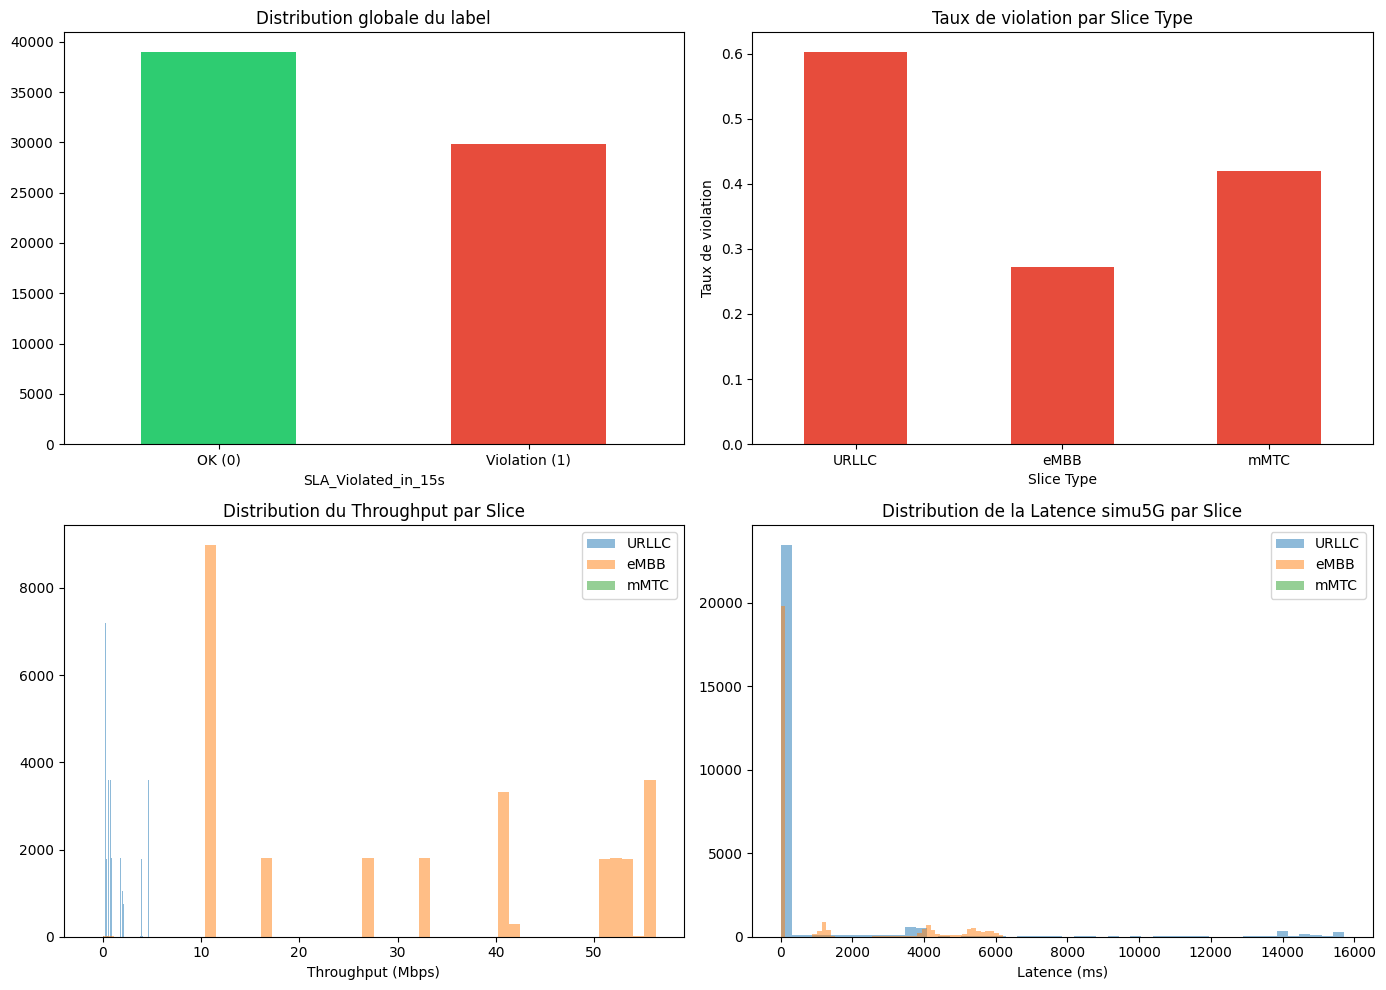

In [7]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Distribution du label
df['SLA_Violated_in_15s'].value_counts().plot.bar(ax=axes[0, 0], color=['#2ecc71', '#e74c3c'])
axes[0, 0].set_title('Distribution globale du label')
axes[0, 0].set_xticklabels(['OK (0)', 'Violation (1)'], rotation=0)

# Violations par slice
df.groupby('Slice Type')['SLA_Violated_in_15s'].mean().plot.bar(ax=axes[0, 1], color='#e74c3c')
axes[0, 1].set_title('Taux de violation par Slice Type')
axes[0, 1].set_ylabel('Taux de violation')
axes[0, 1].tick_params(axis='x', rotation=0)

# Distribution du throughput par slice
for st in df['Slice Type'].unique():
    subset = df[df['Slice Type'] == st]
    axes[1, 0].hist(subset['Slice_Throughput_Mbps'], bins=50, alpha=0.5, label=st)
axes[1, 0].set_title('Distribution du Throughput par Slice')
axes[1, 0].set_xlabel('Throughput (Mbps)')
axes[1, 0].legend()

# Distribution de la latence par slice
for st in df['Slice Type'].unique():
    subset = df[df['Slice Type'] == st]
    axes[1, 1].hist(subset['Slice_Latency_ms'], bins=50, alpha=0.5, label=st)
axes[1, 1].set_title('Distribution de la Latence simu5G par Slice')
axes[1, 1].set_xlabel('Latence (ms)')
axes[1, 1].legend()

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'exploration_distributions_simu5g.png'), dpi=150)
plt.show()

In [8]:
# Stats descriptives des features numeriques
numeric_cols = ['Slice_Throughput_Mbps', 'Slice_Jitter_ms', 'Slice_Packet_Loss_pct',
                'Slice_Network_Load_pct', 'Slice_Latency_ms']
df[numeric_cols].describe().round(4)

,Slice_Throughput_Mbps,Slice_Jitter_ms,Slice_Packet_Loss_pct,Slice_Network_Load_pct,Slice_Latency_ms
count,68797.0000,68797.0000,68797.0000,68797.0000,68797.0000
mean,13.2081,29.4552,0.0900,24.5237,800.5959
std,19.1236,108.0809,0.3833,26.0419,2356.9551
min,-1.0964,0.0000,0.0000,-1.0964,0.8776
25%,0.3107,0.0048,0.0000,6.2138,14.3150
50%,1.8688,0.0231,0.0000,12.4742,15.5099
75%,16.2953,0.2329,0.0000,41.2800,16.7856
max,56.2440,6616.8968,1.9536,93.9072,15722.8254


In [9]:
# Stats descriptives par Slice Type
print('=== Statistiques par Slice Type ===')
for st in sorted(df['Slice Type'].unique()):
    subset = df[df['Slice Type'] == st]
    print(f'\n--- {st} ({len(subset)} lignes) ---')
    print(subset[numeric_cols].describe().round(4))

=== Statistiques par Slice Type ===

--- URLLC (27013 lignes) ---
       Slice_Throughput_Mbps  Slice_Jitter_ms  Slice_Packet_Loss_pct  \
count             27013.0000       27013.0000             27013.0000   
mean                  1.5141          47.8926                 0.2292   
std                   1.5579         159.6641                 0.5851   
min                   0.0097           0.0000                 0.0000   
25%                   0.3130           0.0008                 0.0000   
50%                   0.7779           0.0125                 0.0000   
75%                   2.0604           0.9790                 0.0000   
max                   4.6954        6616.8968                 1.9536   

       Slice_Network_Load_pct  Slice_Latency_ms  
count              27013.0000        27013.0000  
mean                  30.2829          980.8660  
std                   31.1587         3153.0781  
min                    0.1946            0.8776  
25%                    6.2605      

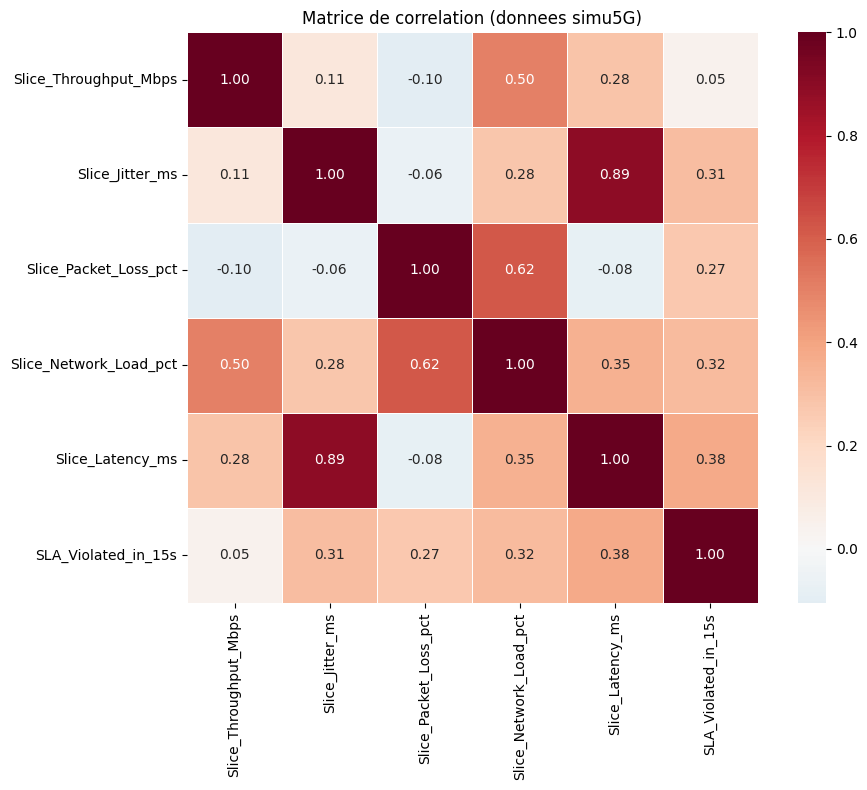

In [10]:
# Matrice de correlation des features numeriques
fig, ax = plt.subplots(figsize=(10, 8))
corr_cols = numeric_cols + ['SLA_Violated_in_15s']
corr = df[corr_cols].corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdBu_r', center=0, ax=ax,
            square=True, linewidths=0.5)
ax.set_title('Matrice de correlation (donnees simu5G)')
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'correlation_matrix_simu5g.png'), dpi=150)
plt.show()

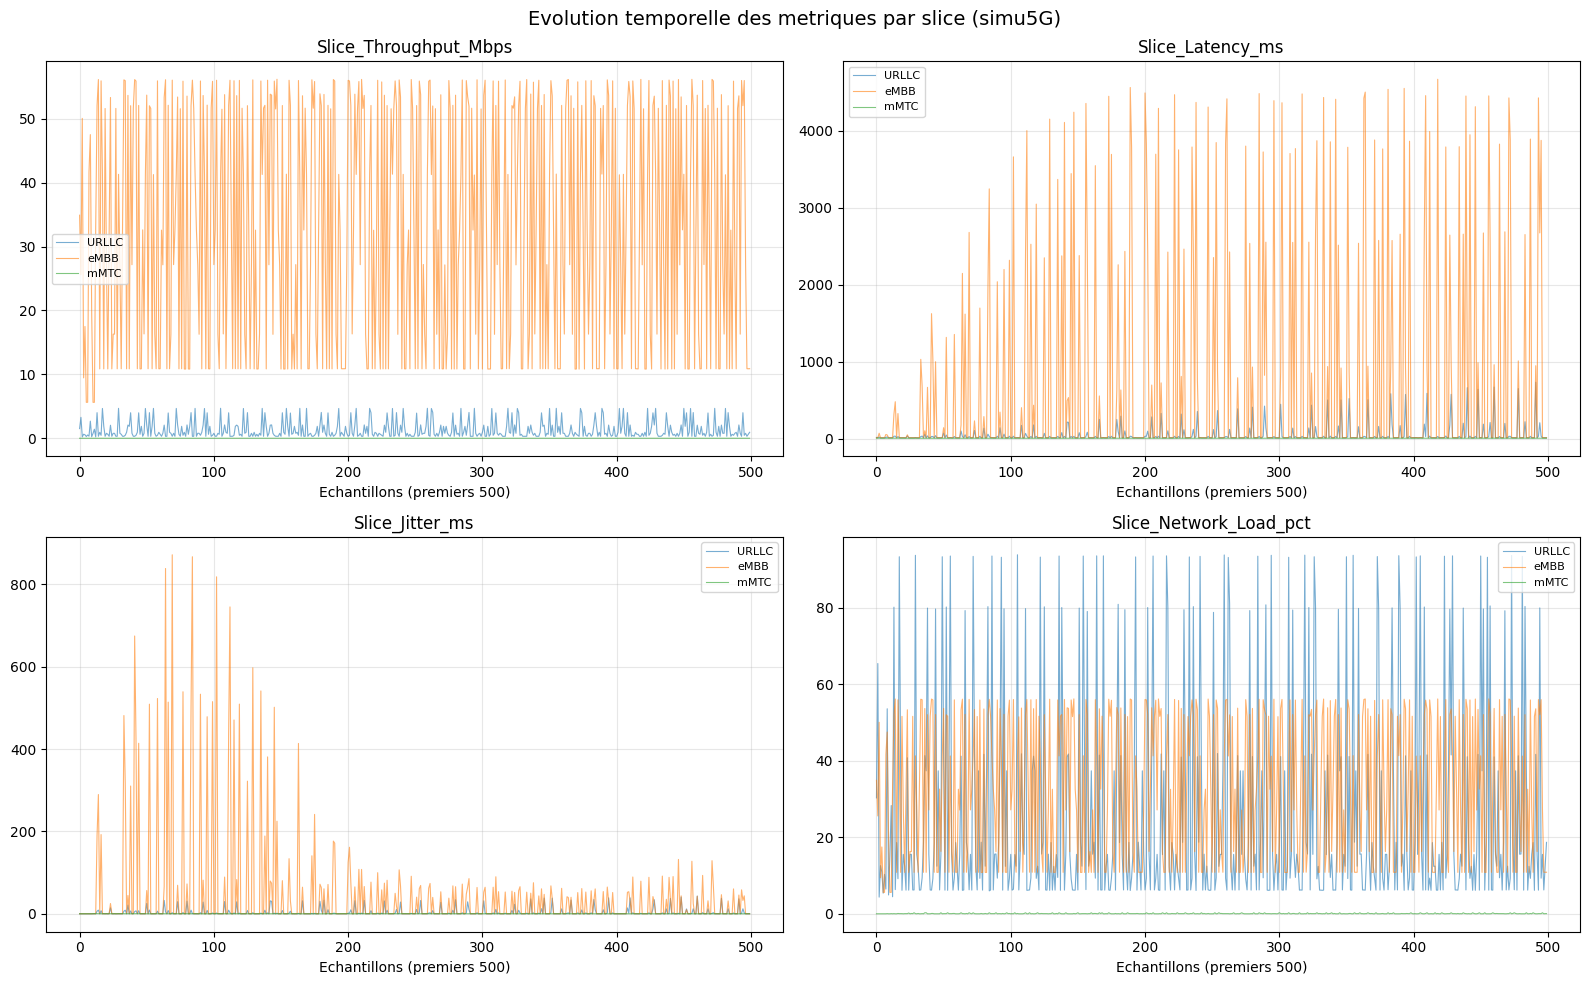

In [11]:
# Evolution temporelle des metriques par slice (echantillon)
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

df_temp = df.copy()
df_temp['Time_Sec'] = pd.to_datetime(df_temp['Time_Sec'])

for idx, (metric, ax) in enumerate(zip(
    ['Slice_Throughput_Mbps', 'Slice_Latency_ms', 'Slice_Jitter_ms', 'Slice_Network_Load_pct'],
    axes.flat
)):
    for st in sorted(df_temp['Slice Type'].unique()):
        subset = df_temp[df_temp['Slice Type'] == st].sort_values('Time_Sec')
        # Prendre les 500 premiers points pour la lisibilite
        subset_sample = subset.head(500)
        ax.plot(range(len(subset_sample)), subset_sample[metric], alpha=0.6, label=st, linewidth=0.8)
    ax.set_title(metric)
    ax.set_xlabel('Echantillons (premiers 500)')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

plt.suptitle('Evolution temporelle des metriques par slice (simu5G)', fontsize=14)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'temporal_evolution_simu5g.png'), dpi=150)
plt.show()

## 3. Preprocessing

Donnees simu5G : 13 scenarios de simulation, 3 slices (eMBB, URLLC, mMTC).
Labels SLA calcules avec horizon 15s par le script d'extraction.

**Anti-overfitting** : Split **leave-one-scenario-out** :
- Le modele s'entraine sur N-1 scenarios et predit sur des scenarios jamais vus.
- Les sequences sont construites par (scenario, slice) pour eviter la contamination.
- GroupKFold CV avec le scenario comme groupe.

**Features** : 24 features (5 metriques + 15 derivees + 4 one-hot slices).


In [12]:
# --- 3.1 Verification de Packet Loss (conserve comme feature) ---
print(f'Packet Loss - valeurs uniques : {df["Slice_Packet_Loss_pct"].nunique()}')
print(f'Packet Loss - max : {df["Slice_Packet_Loss_pct"].max():.4f}%')
print(f'Packet Loss - mean : {df["Slice_Packet_Loss_pct"].mean():.4f}%')
print('-> Slice_Packet_Loss_pct CONSERVE (non-zero variance avec les nouveaux scenarios)')

# Distribution par slice
print('\n--- Packet Loss par Slice ---')
for st in sorted(df['Slice Type'].unique()):
    subset = df[df['Slice Type'] == st]['Slice_Packet_Loss_pct']
    print(f'  {st:14s} : mean={subset.mean():.6f}%, max={subset.max():.4f}%, nunique={subset.nunique()}')

Packet Loss - valeurs uniques : 24
Packet Loss - max : 1.9536%
Packet Loss - mean : 0.0900%
-> Slice_Packet_Loss_pct CONSERVE (non-zero variance avec les nouveaux scenarios)

--- Packet Loss par Slice ---
  URLLC          : mean=0.229159%, max=1.9536%, nunique=24
  eMBB           : mean=0.000000%, max=0.0000%, nunique=1
  mMTC           : mean=0.000000%, max=0.0000%, nunique=1


In [13]:
# --- 3.2 Verification du Jitter (pas de capping necessaire pour simu5G) ---
p99_jitter = df['Slice_Jitter_ms'].quantile(0.99)
print(f'Jitter P99 : {p99_jitter:.4f} ms')
print(f'Jitter max : {df["Slice_Jitter_ms"].max():.4f} ms')

# On applique quand meme un capping P99 par coherence avec l'approche A
df['Slice_Jitter_ms'] = df['Slice_Jitter_ms'].clip(upper=p99_jitter)
print(f'Jitter max apres capping P99 : {df["Slice_Jitter_ms"].max():.4f} ms')

Jitter P99 : 657.7517 ms
Jitter max : 6616.8968 ms
Jitter max apres capping P99 : 657.7517 ms


In [14]:
# --- 3.3 Parsing du timestamp et tri ---
# Time_Sec deja converti en datetime dans la cellule precedente
df = df.sort_values(['Scenario', 'Slice Type', 'Time_Sec']).reset_index(drop=True)

print(f'Plage temporelle : {df["Time_Sec"].min()} -> {df["Time_Sec"].max()}')
print(f'Duree : {(df["Time_Sec"].max() - df["Time_Sec"].min()).total_seconds() / 3600:.1f} heures')

Plage temporelle : 2024-01-01 00:00:00+00:00 -> 2024-01-01 01:00:00+00:00
Duree : 1.0 heures


In [15]:
# --- 3.4 Feature Engineering : moyennes glissantes et tendances ---
# On calcule par slice pour eviter le melange inter-slices
# PacketLoss est maintenant inclus dans les features

feature_cols = ['Slice_Throughput_Mbps', 'Slice_Jitter_ms', 'Slice_Packet_Loss_pct',
                'Slice_Network_Load_pct', 'Slice_Latency_ms']

for col in feature_cols:
    # Moyenne glissante 5s
    df[f'{col}_ma5'] = df.groupby(['Scenario', 'Slice Type'])[col].transform(
        lambda x: x.rolling(5, min_periods=1).mean()
    )
    # Moyenne glissante 10s
    df[f'{col}_ma10'] = df.groupby(['Scenario', 'Slice Type'])[col].transform(
        lambda x: x.rolling(10, min_periods=1).mean()
    )
    # Derivee (variation par rapport a t-1)
    df[f'{col}_diff'] = df.groupby(['Scenario', 'Slice Type'])[col].transform(
        lambda x: x.diff().fillna(0)
    )

print(f'Features de base : {len(feature_cols)} ({feature_cols})')
print(f'Features derivees : {len(feature_cols) * 3} (ma5, ma10, diff pour chaque)')
print(f'Total features : {len(feature_cols) + len(feature_cols) * 3} = {len(feature_cols) * 4}')
print(f'(+ 4 one-hot slice type en cellule suivante)')

Features de base : 5 (['Slice_Throughput_Mbps', 'Slice_Jitter_ms', 'Slice_Packet_Loss_pct', 'Slice_Network_Load_pct', 'Slice_Latency_ms'])
Features derivees : 15 (ma5, ma10, diff pour chaque)
Total features : 20 = 20
(+ 4 one-hot slice type en cellule suivante)


In [16]:
# --- 3.5 Encoding du Slice Type (one-hot) ---
slice_dummies = pd.get_dummies(df['Slice Type'], prefix='slice')
df = pd.concat([df, slice_dummies], axis=1)

# Convertir en float
for col in slice_dummies.columns:
    df[col] = df[col].astype(float)

print('Colonnes one-hot :', list(slice_dummies.columns))

Colonnes one-hot : ['slice_URLLC', 'slice_eMBB', 'slice_mMTC']


In [17]:
# --- 3.6 Selection des features finales ---
# Avec le split leave-one-scenario-out, le modele doit generaliser a des
# scenarios jamais vus. Meme avec les metriques brutes, il ne peut pas
# memoriser les patterns specifiques du scenario de test.

input_features = (
    feature_cols +
    [f'{c}_ma5' for c in feature_cols] +
    [f'{c}_ma10' for c in feature_cols] +
    [f'{c}_diff' for c in feature_cols] +
    list(slice_dummies.columns)
)

target_col = 'SLA_Violated_in_15s'

print(f'Features ({len(input_features)}) :')
for i, feat in enumerate(input_features):
    print(f'  {i+1:2d}. {feat}')

Features (23) :
   1. Slice_Throughput_Mbps
   2. Slice_Jitter_ms
   3. Slice_Packet_Loss_pct
   4. Slice_Network_Load_pct
   5. Slice_Latency_ms
   6. Slice_Throughput_Mbps_ma5
   7. Slice_Jitter_ms_ma5
   8. Slice_Packet_Loss_pct_ma5
   9. Slice_Network_Load_pct_ma5
  10. Slice_Latency_ms_ma5
  11. Slice_Throughput_Mbps_ma10
  12. Slice_Jitter_ms_ma10
  13. Slice_Packet_Loss_pct_ma10
  14. Slice_Network_Load_pct_ma10
  15. Slice_Latency_ms_ma10
  16. Slice_Throughput_Mbps_diff
  17. Slice_Jitter_ms_diff
  18. Slice_Packet_Loss_pct_diff
  19. Slice_Network_Load_pct_diff
  20. Slice_Latency_ms_diff
  21. slice_URLLC
  22. slice_eMBB
  23. slice_mMTC


In [18]:
# --- 3.7 Normalisation MinMaxScaler ---
# Normaliser TOUTES les features continues d'abord, puis on fera le split stratifie
# apres la construction des sequences

continuous_features = [f for f in input_features if f not in slice_dummies.columns]

scaler = MinMaxScaler()
df[continuous_features] = scaler.fit_transform(df[continuous_features])

print(f'Normalisation MinMaxScaler sur {len(continuous_features)} features continues')
print(f'Features one-hot non scalees : {list(slice_dummies.columns)}')

Normalisation MinMaxScaler sur 20 features continues
Features one-hot non scalees : ['slice_URLLC', 'slice_eMBB', 'slice_mMTC']


## 4. Construction des sequences LSTM + split par scenario

- **Lookback** = 30 secondes d'historique par sequence
- **Labels originaux** : SLA_Violated_in_15s (horizon 15s, seuils de l'extraction)
- **Sequences par (scenario, slice)** : pas de contamination inter-scenarios
- **Split leave-one-scenario-out** : train sur 10 scenarios, test sur 3 scenarios
  Le modele doit generaliser a des conditions reseau jamais vues.


In [19]:
from sklearn.model_selection import train_test_split

LOOKBACK = 30

def create_sequences(data, features, target, lookback):
    X, y = [], []
    values = data[features].values
    labels = data[target].values
    for i in range(lookback, len(values)):
        X.append(values[i - lookback:i])
        y.append(labels[i])
    return np.array(X), np.array(y)

# Construction par (scenario, slice) pour respecter les frontieres temporelles
X_all_list, y_all_list, slice_labels_list, scenario_labels_list = [], [], [], []

scenarios = sorted(df['Scenario'].unique())
print(f'Scenarios disponibles ({len(scenarios)}) : {scenarios}')

for scenario in scenarios:
    for slice_type in sorted(df['Slice Type'].unique()):
        subset = df[(df['Scenario'] == scenario) & (df['Slice Type'] == slice_type)]
        subset = subset.sort_values('Time_Sec')

        if len(subset) > LOOKBACK:
            X_s, y_s = create_sequences(subset, input_features, target_col, LOOKBACK)
            X_all_list.append(X_s)
            y_all_list.append(y_s)
            slice_labels_list.extend([slice_type] * len(y_s))
            scenario_labels_list.extend([scenario] * len(y_s))

X_all = np.concatenate(X_all_list)
y_all = np.concatenate(y_all_list)
slice_labels = np.array(slice_labels_list)
scenario_labels = np.array(scenario_labels_list)

print(f'Total : {X_all.shape} sequences')

# --- Split leave-one-scenario-out ---
# Test sur 3 scenarios diversifies (normal + stress + mixte)
TEST_SCENARIOS = ['MediumLoad', 'ExtremeLoad', 'RealTraffic']
TRAIN_SCENARIOS = [s for s in scenarios if s not in TEST_SCENARIOS]

train_mask = np.isin(scenario_labels, TRAIN_SCENARIOS)
test_mask = np.isin(scenario_labels, TEST_SCENARIOS)

X_train, y_train = X_all[train_mask], y_all[train_mask]
X_test, y_test = X_all[test_mask], y_all[test_mask]
sl_train, sl_test = slice_labels[train_mask], slice_labels[test_mask]
sc_train, sc_test = scenario_labels[train_mask], scenario_labels[test_mask]

print(f'\n--- Split par scenario ---')
print(f'Train scenarios ({len(TRAIN_SCENARIOS)}) : {TRAIN_SCENARIOS}')
print(f'Test scenarios  ({len(TEST_SCENARIOS)})  : {TEST_SCENARIOS}')
print(f'X_train : {X_train.shape}  | violations : {y_train.mean():.2%}')
print(f'X_test  : {X_test.shape}  | violations : {y_test.mean():.2%}')

print('\n--- Violations par slice (train) ---')
for st in sorted(set(sl_train)):
    mask = sl_train == st
    print(f'  {st:12s} : {mask.sum():6d} seq | {y_train[mask].sum():5.0f} violations ({y_train[mask].mean():.2%})')

print('\n--- Violations par slice (test) ---')
for st in sorted(set(sl_test)):
    mask = sl_test == st
    print(f'  {st:12s} : {mask.sum():6d} seq | {y_test[mask].sum():5.0f} violations ({y_test[mask].mean():.2%})')

print('\n--- Violations par scenario (test) ---')
for sc in TEST_SCENARIOS:
    mask = sc_test == sc
    print(f'  {sc:25s} : {mask.sum():6d} seq | {y_test[mask].sum():5.0f} violations ({y_test[mask].mean():.2%})')

Scenarios disponibles (13) : ['CongestionHigh', 'ExtremeLoad', 'HeavyEmbb', 'MediumLoad', 'Normal', 'OverloadAll', 'OverloadEmbb', 'OverloadUrllc', 'RealTraffic', 'RealTrafficOverload', 'StressEmbb', 'TransitionEmbb', 'TransitionUrllc']
Total : (67627, 30, 23) sequences

--- Split par scenario ---
Train scenarios (10) : ['CongestionHigh', 'HeavyEmbb', 'Normal', 'OverloadAll', 'OverloadEmbb', 'OverloadUrllc', 'RealTrafficOverload', 'StressEmbb', 'TransitionEmbb', 'TransitionUrllc']
Test scenarios  (3)  : ['MediumLoad', 'ExtremeLoad', 'RealTraffic']
X_train : (49528, 30, 23)  | violations : 51.92%
X_test  : (18099, 30, 23)  | violations : 20.12%

--- Violations par slice (train) ---
  URLLC        :  19510 seq | 14235 violations (72.96%)
  eMBB         :  19510 seq |  5415 violations (27.75%)
  mMTC         :  10508 seq |  6067 violations (57.74%)

--- Violations par slice (test) ---
  URLLC        :   7113 seq |  1800 violations (25.31%)
  eMBB         :   7113 seq |  1800 violations (2

## 5. Modele LSTM (PyTorch)

Architecture :
```
Input (30, 24)
  -> LSTM(64, num_layers=1)
  -> Dropout(0.3)
  -> LSTM(32, num_layers=1)
  -> Dropout(0.3)
  -> Linear(32, 16) + ReLU
  -> Linear(16, 1)
```

Modele global entraine sur les 4 slices.
`BCEWithLogitsLoss` avec `pos_weight` pour gerer le desequilibre (13% violations).

In [20]:
# --- Dataset PyTorch ---
class SLADataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.FloatTensor(X)
        self.y = torch.FloatTensor(y)

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

# --- Modele LSTM ---
class LSTMModel(nn.Module):
    def __init__(self, n_features, hidden1=64, hidden2=32, dropout=0.3):
        super().__init__()
        self.lstm1 = nn.LSTM(n_features, hidden1, batch_first=True)
        self.dropout1 = nn.Dropout(dropout)
        self.lstm2 = nn.LSTM(hidden1, hidden2, batch_first=True)
        self.dropout2 = nn.Dropout(dropout)
        self.fc1 = nn.Linear(hidden2, 16)
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(16, 1)

    def forward(self, x):
        out, _ = self.lstm1(x)
        out = self.dropout1(out)
        out, _ = self.lstm2(out)
        out = self.dropout2(out[:, -1, :])  # dernier pas de temps
        out = self.relu(self.fc1(out))
        out = self.fc2(out)
        return out.squeeze(-1)

n_features = X_train.shape[2]
model = LSTMModel(n_features).to(device)

print(model)
total_params = sum(p.numel() for p in model.parameters())
print(f'\nTotal parametres : {total_params:,}')

LSTMModel(
  (lstm1): LSTM(23, 64, batch_first=True)
  (dropout1): Dropout(p=0.3, inplace=False)
  (lstm2): LSTM(64, 32, batch_first=True)
  (dropout2): Dropout(p=0.3, inplace=False)
  (fc1): Linear(in_features=32, out_features=16, bias=True)
  (relu): ReLU()
  (fc2): Linear(in_features=16, out_features=1, bias=True)
)

Total parametres : 35,873


In [21]:
# Class weights : pos_weight pour BCEWithLogitsLoss
n_pos = y_train.sum()
n_neg = len(y_train) - n_pos
pos_weight = torch.FloatTensor([n_neg / n_pos]).to(device)

print(f'Classe 0 (OK)        : {n_neg:,.0f} samples')
print(f'Classe 1 (Violation) : {n_pos:,.0f} samples')
print(f'pos_weight           : {pos_weight.item():.3f}')

criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=0.5, patience=3
)

BATCH_SIZE = 256

# DataLoaders
train_dataset = SLADataset(X_train, y_train)
# Split train -> train_fit (80%) + val (20%)
val_size = int(0.2 * len(train_dataset))
train_size = len(train_dataset) - val_size
train_fit, val_set = torch.utils.data.random_split(train_dataset, [train_size, val_size])

train_loader = DataLoader(train_fit, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_set, batch_size=BATCH_SIZE, shuffle=False)
test_dataset = SLADataset(X_test, y_test)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

print(f'\nTrain fit : {train_size:,} samples')
print(f'Validation: {val_size:,} samples')
print(f'Test      : {len(test_dataset):,} samples')

Classe 0 (OK)        : 23,811 samples
Classe 1 (Violation) : 25,717 samples
pos_weight           : 0.926

Train fit : 39,623 samples
Validation: 9,905 samples
Test      : 18,099 samples


## 6. Entrainement

In [22]:
EPOCHS = 50
PATIENCE = 5

history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}
best_val_loss = float('inf')
patience_counter = 0
best_state = None

for epoch in range(EPOCHS):
    # --- Train ---
    model.train()
    train_loss, correct, total = 0, 0, 0

    for X_batch, y_batch in train_loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)

        optimizer.zero_grad()
        logits = model(X_batch)
        loss = criterion(logits, y_batch)
        loss.backward()
        optimizer.step()

        train_loss += loss.item() * len(y_batch)
        preds = (torch.sigmoid(logits) >= 0.5).float()
        correct += (preds == y_batch).sum().item()
        total += len(y_batch)

    train_loss /= total
    train_acc = correct / total

    # --- Validation ---
    model.eval()
    val_loss, correct, total = 0, 0, 0

    with torch.no_grad():
        for X_batch, y_batch in val_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            logits = model(X_batch)
            loss = criterion(logits, y_batch)

            val_loss += loss.item() * len(y_batch)
            preds = (torch.sigmoid(logits) >= 0.5).float()
            correct += (preds == y_batch).sum().item()
            total += len(y_batch)

    val_loss /= total
    val_acc = correct / total

    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)
    history['train_acc'].append(train_acc)
    history['val_acc'].append(val_acc)

    scheduler.step(val_loss)

    # Early stopping
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_state = model.state_dict().copy()
        patience_counter = 0
        marker = ' *'
    else:
        patience_counter += 1
        marker = ''

    print(f'Epoch {epoch+1:3d}/{EPOCHS} | '
          f'Train Loss: {train_loss:.4f} Acc: {train_acc:.4f} | '
          f'Val Loss: {val_loss:.4f} Acc: {val_acc:.4f}{marker}')

    if patience_counter >= PATIENCE:
        print(f'\nEarly stopping a l\'epoch {epoch+1}')
        break

# Restaurer les meilleurs poids
model.load_state_dict(best_state)
print(f'\nMeilleurs poids restaures (val_loss = {best_val_loss:.4f})')

Epoch   1/50 | Train Loss: 0.5626 Acc: 0.6632 | Val Loss: 0.5253 Acc: 0.6987 *
Epoch   2/50 | Train Loss: 0.3427 Acc: 0.8079 | Val Loss: 0.2461 Acc: 0.9025 *
Epoch   3/50 | Train Loss: 0.1687 Acc: 0.9043 | Val Loss: 0.1616 Acc: 0.9026 *
Epoch   4/50 | Train Loss: 0.1586 Acc: 0.9060 | Val Loss: 0.1602 Acc: 0.9026 *
Epoch   5/50 | Train Loss: 0.1587 Acc: 0.9076 | Val Loss: 0.1606 Acc: 0.9026
Epoch   6/50 | Train Loss: 0.1686 Acc: 0.9048 | Val Loss: 0.1608 Acc: 0.9026
Epoch   7/50 | Train Loss: 0.1580 Acc: 0.9078 | Val Loss: 0.1608 Acc: 0.9026
Epoch   8/50 | Train Loss: 0.1583 Acc: 0.9082 | Val Loss: 0.1605 Acc: 0.9026
Epoch   9/50 | Train Loss: 0.1581 Acc: 0.9082 | Val Loss: 0.1604 Acc: 0.9026

Early stopping a l'epoch 9

Meilleurs poids restaures (val_loss = 0.1602)


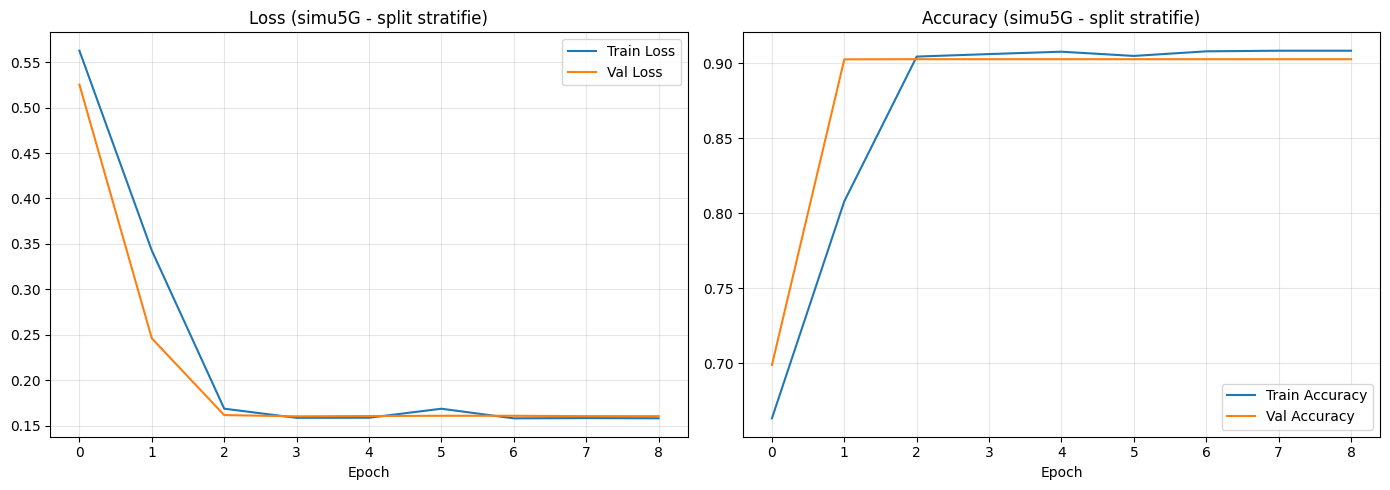

In [23]:
# Courbes d'entrainement
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history['train_loss'], label='Train Loss')
axes[0].plot(history['val_loss'], label='Val Loss')
axes[0].set_title('Loss (simu5G - split stratifie)')
axes[0].set_xlabel('Epoch')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(history['train_acc'], label='Train Accuracy')
axes[1].plot(history['val_acc'], label='Val Accuracy')
axes[1].set_title('Accuracy (simu5G - split stratifie)')
axes[1].set_xlabel('Epoch')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'training_curves_simu5g.png'), dpi=150)
plt.show()

## 7. Evaluation

In [24]:
# Predictions sur le test set + Temperature Scaling
model.eval()
all_logits = []

with torch.no_grad():
    for X_batch, _ in test_loader:
        X_batch = X_batch.to(device)
        logits = model(X_batch)
        all_logits.append(logits.cpu())

test_logits = torch.cat(all_logits)

# --- Temperature Scaling (calibration des probabilites) ---
# Probleme : le modele produit des logits tres eleves, sigmoid sature pres de 1.0
# Solution : diviser les logits par T > 1 pour etaler les probabilites
# T est optimise sur le validation set (minimise la NLL)
from scipy.optimize import minimize_scalar

val_logits_list, val_labels_list = [], []
with torch.no_grad():
    for X_batch, y_batch in val_loader:
        X_batch = X_batch.to(device)
        val_logits_list.append(model(X_batch).cpu())
        val_labels_list.append(y_batch)

val_logits_t = torch.cat(val_logits_list)
val_labels_t = torch.cat(val_labels_list)

def nll_temperature(T):
    scaled = val_logits_t / T
    return nn.functional.binary_cross_entropy_with_logits(scaled, val_labels_t).item()

result = minimize_scalar(nll_temperature, bounds=(0.1, 50.0), method="bounded")
temperature = result.x

# Appliquer la calibration
y_pred_proba_raw = torch.sigmoid(test_logits).numpy()
y_pred_proba = torch.sigmoid(test_logits / temperature).numpy()
y_pred = (y_pred_proba >= 0.5).astype(int)

print(f"Temperature optimale : {temperature:.2f}")
print(f"Plage probas AVANT calibration : [{y_pred_proba_raw.min():.4f}, {y_pred_proba_raw.max():.4f}]")
print(f"Plage probas APRES calibration : [{y_pred_proba.min():.4f}, {y_pred_proba.max():.4f}]")
print()

print("=== Classification Report (global, seuil 0.5, probas calibrees) ===")
print(classification_report(y_test, y_pred, target_names=["OK", "Violation"]))

print(f"F1-score      : {f1_score(y_test, y_pred):.4f}")
print(f"AUC-ROC       : {roc_auc_score(y_test, y_pred_proba):.4f}")


Temperature optimale : 1.06
Plage probas AVANT calibration : [0.0061, 0.9998]
Plage probas APRES calibration : [0.0082, 0.9997]

=== Classification Report (global, seuil 0.5, probas calibrees) ===
              precision    recall  f1-score   support

          OK       0.99      0.73      0.85     14457
   Violation       0.48      0.98      0.65      3642

    accuracy                           0.78     18099
   macro avg       0.74      0.86      0.75     18099
weighted avg       0.89      0.78      0.81     18099

F1-score      : 0.6479
AUC-ROC       : 0.9871


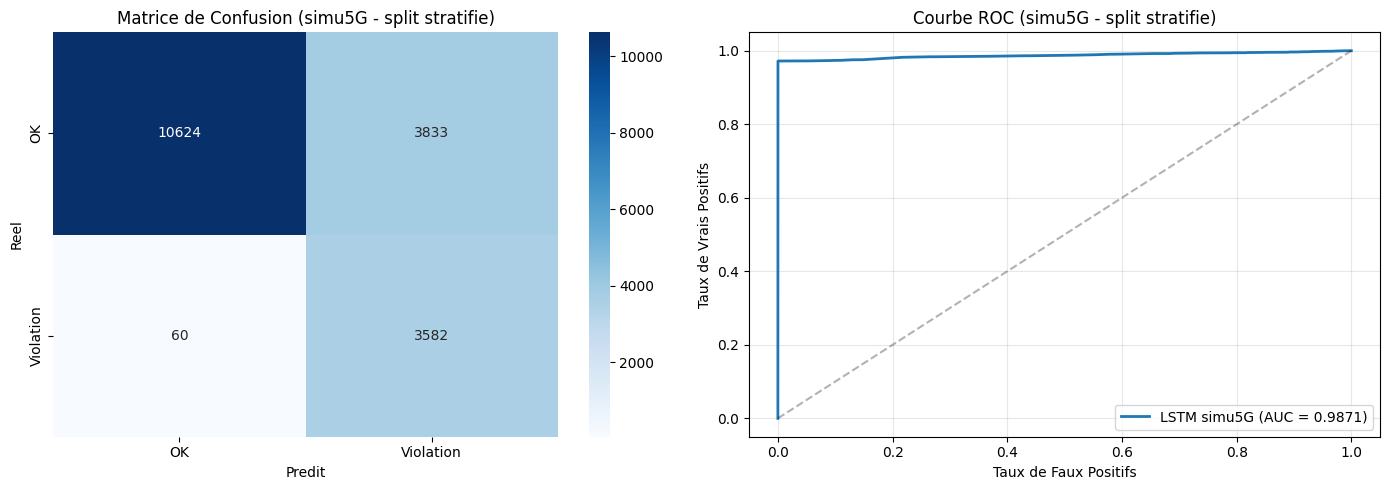

In [25]:
# Confusion Matrix + ROC
cm = confusion_matrix(y_test, y_pred)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Matrice de confusion
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['OK', 'Violation'], yticklabels=['OK', 'Violation'])
axes[0].set_title('Matrice de Confusion (simu5G - split stratifie)')
axes[0].set_ylabel('Reel')
axes[0].set_xlabel('Predit')

# Courbe ROC
fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
auc = roc_auc_score(y_test, y_pred_proba)
axes[1].plot(fpr, tpr, label=f'LSTM simu5G (AUC = {auc:.4f})', linewidth=2)
axes[1].plot([0, 1], [0, 1], 'k--', alpha=0.3)
axes[1].set_title('Courbe ROC (simu5G - split stratifie)')
axes[1].set_xlabel('Taux de Faux Positifs')
axes[1].set_ylabel('Taux de Vrais Positifs')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'evaluation_results_simu5g.png'), dpi=150)
plt.show()

In [26]:
# --- Evaluation par Slice Type ---
print('=== Resultats par Slice Type ===')
print(f'{"Slice":>14s} | {"F1":>6s} | {"Precision":>9s} | {"Recall":>6s} | {"AUC":>6s} | {"Support":>7s} | {"Violations":>10s}')
print('-' * 80)

results_per_slice = {}
for st in sorted(set(sl_test)):
    mask = sl_test == st
    if mask.sum() == 0:
        continue
    yt = y_test[mask]
    yp = y_pred[mask]
    ypp = y_pred_proba[mask]

    f1 = f1_score(yt, yp, zero_division=0)
    tp = ((yp == 1) & (yt == 1)).sum()
    fp = ((yp == 1) & (yt == 0)).sum()
    fn = ((yp == 0) & (yt == 1)).sum()
    prec = tp / (tp + fp) if (tp + fp) > 0 else 0
    rec = tp / (tp + fn) if (tp + fn) > 0 else 0

    if len(np.unique(yt)) > 1:
        auc_val = roc_auc_score(yt, ypp)
    else:
        auc_val = float('nan')

    n_viol = int(yt.sum())
    results_per_slice[st] = {'F1': f1, 'Precision': prec, 'Recall': rec,
                             'AUC': auc_val, 'Support': mask.sum(), 'Violations': n_viol}
    print(f'{st:>14s} | {f1:>6.4f} | {prec:>9.4f} | {rec:>6.4f} | {auc_val:>6.4f} | {mask.sum():>7d} | {n_viol:>10d}')

print('-' * 80)
print(f'{"GLOBAL":>14s} | {f1_score(y_test, y_pred):>6.4f} | '
      f'{"":>9s} | {"":>6s} | {roc_auc_score(y_test, y_pred_proba):>6.4f} | {len(y_test):>7d} | {int(y_test.sum()):>10d}')

=== Resultats par Slice Type ===
         Slice |     F1 | Precision | Recall |    AUC | Support | Violations
--------------------------------------------------------------------------------
         URLLC | 0.9913 |    0.9994 | 0.9833 | 0.9900 |    7113 |       1800
          eMBB | 0.9913 |    0.9994 | 0.9833 | 0.9903 |    7113 |       1800
          mMTC | 0.0215 |    0.0108 | 1.0000 | 0.3803 |    3873 |         42
--------------------------------------------------------------------------------
        GLOBAL | 0.6479 |           |        | 0.9871 |   18099 |       3642


In [27]:
# --- Optimisation du seuil de decision par slice (probas calibrees) ---
from sklearn.metrics import precision_recall_curve

print("=== Optimisation du seuil de decision (probas calibrees) ===")
print(f"Temperature utilisee : {temperature:.2f}")
print()
print(f'{"Slice":>14s} | {"Seuil opt":>9s} | {"F1 (0.5)":>8s} | {"F1 (opt)":>8s} | {"Prec":>6s} | {"Rec":>6s}')
print("-" * 75)

optimal_thresholds = {}
for st in sorted(set(sl_test)):
    mask = sl_test == st
    yt = y_test[mask]
    ypp = y_pred_proba[mask]

    if len(np.unique(yt)) < 2 or yt.sum() == 0:
        print(f'{st:>14s} | {"N/A":>9s} | {"N/A":>8s} | {"N/A":>8s} | (pas assez de violations)')
        continue

    yp_05 = (ypp >= 0.5).astype(int)
    f1_05 = f1_score(yt, yp_05, zero_division=0)

    prec_vals, rec_vals, thresholds = precision_recall_curve(yt, ypp)
    f1_vals = np.where(
        (prec_vals + rec_vals) > 0,
        2 * prec_vals * rec_vals / (prec_vals + rec_vals),
        0
    )
    best_idx = np.argmax(f1_vals)
    best_threshold = thresholds[best_idx] if best_idx < len(thresholds) else 0.5
    best_f1 = f1_vals[best_idx]
    best_prec = prec_vals[best_idx]
    best_rec = rec_vals[best_idx]

    optimal_thresholds[st] = best_threshold
    delta = best_f1 - f1_05
    indicator = f" (+{delta:.3f})" if delta > 0.01 else ""
    print(f'{st:>14s} | {best_threshold:>9.4f} | {f1_05:>8.4f} | {best_f1:>8.4f}{indicator} | {best_prec:>6.4f} | {best_rec:>6.4f}')

print()
print("=== Resultats avec seuils optimises ===")
y_pred_opt = np.zeros_like(y_pred)
for st in sorted(set(sl_test)):
    mask = sl_test == st
    threshold = optimal_thresholds.get(st, 0.5)
    y_pred_opt[mask] = (y_pred_proba[mask] >= threshold).astype(int)

print(f"F1-score global (seuil 0.5)     : {f1_score(y_test, y_pred):.4f}")
print(f"F1-score global (seuils opt)    : {f1_score(y_test, y_pred_opt):.4f}")

print()
print(f'{"Slice":>14s} | {"Seuil":>6s} | {"F1":>6s} | {"Prec":>6s} | {"Rec":>6s}')
print("-" * 55)
for st in sorted(set(sl_test)):
    mask = sl_test == st
    yt = y_test[mask]
    yp_opt = y_pred_opt[mask]
    threshold = optimal_thresholds.get(st, 0.5)
    f1_val = f1_score(yt, yp_opt, zero_division=0)
    tp = ((yp_opt == 1) & (yt == 1)).sum()
    fp = ((yp_opt == 1) & (yt == 0)).sum()
    fn = ((yp_opt == 0) & (yt == 1)).sum()
    prec = tp / (tp + fp) if (tp + fp) > 0 else 0
    rec = tp / (tp + fn) if (tp + fn) > 0 else 0
    print(f'{st:>14s} | {threshold:>6.3f} | {f1_val:>6.4f} | {prec:>6.4f} | {rec:>6.4f}')


=== Optimisation du seuil de decision (probas calibrees) ===
Temperature utilisee : 1.06

         Slice | Seuil opt | F1 (0.5) | F1 (opt) |   Prec |    Rec
---------------------------------------------------------------------------
         URLLC |    0.9997 |   0.9913 |   0.9913 | 0.9994 | 0.9833
          eMBB |    0.9997 |   0.9913 |   0.9913 | 0.9994 | 0.9833
          mMTC |    0.5512 |   0.0215 |   0.0229 | 0.0116 | 0.8810

=== Resultats avec seuils optimises ===
F1-score global (seuil 0.5)     : 0.6479
F1-score global (seuils opt)    : 0.6897

         Slice |  Seuil |     F1 |   Prec |    Rec
-------------------------------------------------------
         URLLC |  1.000 | 0.9913 | 0.9994 | 0.9833
          eMBB |  1.000 | 0.9913 | 0.9994 | 0.9833
          mMTC |  0.551 | 0.0229 | 0.0116 | 0.8810


C:\Users\Utilisateur\AppData\Local\Temp\ipykernel_47232\262281844.py:26: RuntimeWarning: invalid value encountered in divide
  2 * prec_vals * rec_vals / (prec_vals + rec_vals),


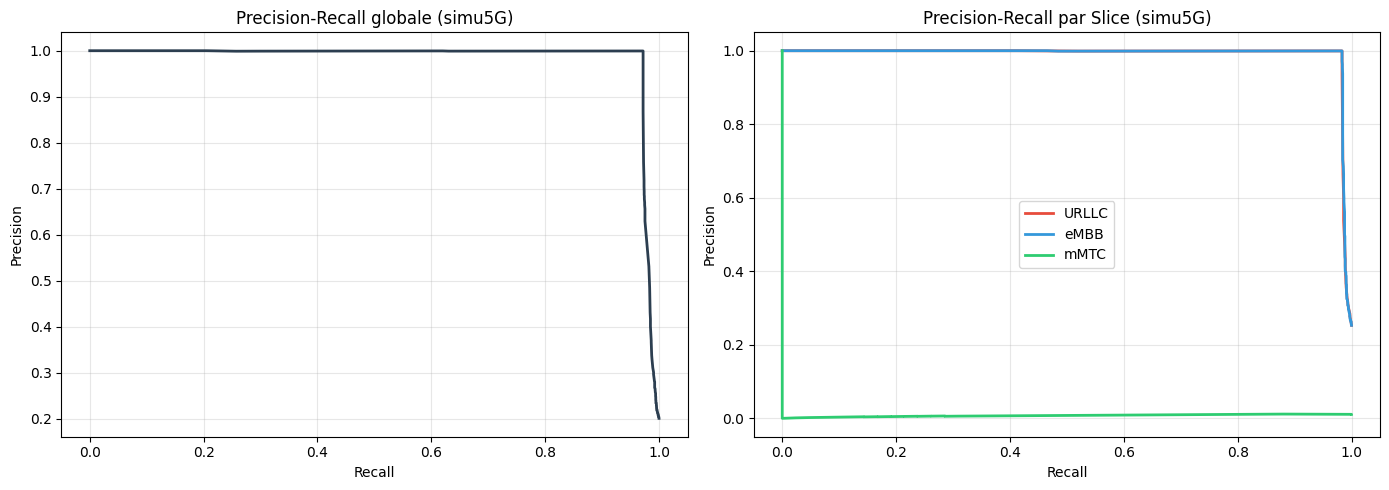

In [28]:
# Courbe Precision-Recall globale + par slice
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Globale
prec_vals, rec_vals, _ = precision_recall_curve(y_test, y_pred_proba)
axes[0].plot(rec_vals, prec_vals, linewidth=2, color='#2c3e50')
axes[0].set_xlabel('Recall')
axes[0].set_ylabel('Precision')
axes[0].set_title('Precision-Recall globale (simu5G)')
axes[0].grid(True, alpha=0.3)

# Par slice
colors = {'URLLC': '#e74c3c', 'eMBB': '#3498db', 'mMTC': '#2ecc71', 'Best Effort': '#95a5a6'}
for st in sorted(set(sl_test)):
    mask = sl_test == st
    yt = y_test[mask]
    ypp = y_pred_proba[mask]
    if len(np.unique(yt)) > 1:
        p, r, _ = precision_recall_curve(yt, ypp)
        axes[1].plot(r, p, linewidth=2, label=st, color=colors.get(st, 'gray'))

axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precision')
axes[1].set_title('Precision-Recall par Slice (simu5G)')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'precision_recall_curve_simu5g.png'), dpi=150)
plt.show()

## 7b. Cross-Validation (GroupKFold par scenario)

Pour evaluer la robustesse, on utilise **GroupKFold** avec le scenario comme groupe.
Chaque fold teste sur 2-3 scenarios jamais vus pendant l'entrainement.
C'est plus realiste que StratifiedKFold qui melange les scenarios.


In [29]:
from sklearn.model_selection import GroupKFold

N_SPLITS = 5
CV_EPOCHS = 30
CV_PATIENCE = 4

gkf = GroupKFold(n_splits=N_SPLITS)

cv_results = []

for fold_idx, (train_idx, val_idx) in enumerate(gkf.split(X_all, y_all, groups=scenario_labels)):
    val_scenarios = sorted(set(scenario_labels[val_idx]))

    print(f'\n{"="*60}')
    print(f'FOLD {fold_idx + 1}/{N_SPLITS}')
    print(f'  Test scenarios : {val_scenarios}')
    print(f'{"="*60}')

    X_cv_train, y_cv_train = X_all[train_idx], y_all[train_idx]
    X_cv_val, y_cv_val = X_all[val_idx], y_all[val_idx]
    sl_cv_val = slice_labels[val_idx]

    n_pos_fold = y_cv_train.sum()
    n_neg_fold = len(y_cv_train) - n_pos_fold

    print(f'Train : {len(X_cv_train):,} sequences | violations : {y_cv_train.mean():.2%}')
    print(f'Val   : {len(X_cv_val):,} sequences | violations : {y_cv_val.mean():.2%}')

    fold_model = LSTMModel(n_features).to(device)
    pw = torch.FloatTensor([n_neg_fold / max(n_pos_fold, 1)]).to(device)
    fold_criterion = nn.BCEWithLogitsLoss(pos_weight=pw)
    fold_optimizer = torch.optim.Adam(fold_model.parameters(), lr=0.001)

    fold_train_loader = DataLoader(
        SLADataset(X_cv_train, y_cv_train), batch_size=BATCH_SIZE, shuffle=True
    )
    fold_val_loader = DataLoader(
        SLADataset(X_cv_val, y_cv_val), batch_size=BATCH_SIZE, shuffle=False
    )

    best_fold_loss = float('inf')
    best_fold_state = None
    fold_patience = 0

    for epoch in range(CV_EPOCHS):
        fold_model.train()
        t_loss, t_total = 0, 0
        for X_b, y_b in fold_train_loader:
            X_b, y_b = X_b.to(device), y_b.to(device)
            fold_optimizer.zero_grad()
            logits = fold_model(X_b)
            loss = fold_criterion(logits, y_b)
            loss.backward()
            fold_optimizer.step()
            t_loss += loss.item() * len(y_b)
            t_total += len(y_b)

        fold_model.eval()
        v_loss, v_total = 0, 0
        with torch.no_grad():
            for X_b, y_b in fold_val_loader:
                X_b, y_b = X_b.to(device), y_b.to(device)
                logits = fold_model(X_b)
                loss = fold_criterion(logits, y_b)
                v_loss += loss.item() * len(y_b)
                v_total += len(y_b)

        v_loss /= v_total
        if v_loss < best_fold_loss:
            best_fold_loss = v_loss
            best_fold_state = fold_model.state_dict().copy()
            fold_patience = 0
        else:
            fold_patience += 1

        if fold_patience >= CV_PATIENCE:
            print(f'  Early stopping epoch {epoch+1}')
            break

    fold_model.load_state_dict(best_fold_state)
    fold_model.eval()

    # Temperature scaling pour ce fold (calibre sur le train set)
    cal_logits_list, cal_labels_list = [], []
    with torch.no_grad():
        for X_b, y_b in fold_train_loader:
            X_b = X_b.to(device)
            cal_logits_list.append(fold_model(X_b).cpu())
            cal_labels_list.append(y_b)
    cal_logits = torch.cat(cal_logits_list)
    cal_labels = torch.cat(cal_labels_list)

    def fold_nll(T):
        return nn.functional.binary_cross_entropy_with_logits(cal_logits / T, cal_labels).item()
    fold_T = minimize_scalar(fold_nll, bounds=(0.1, 50.0), method="bounded").x

    all_logits_cv = []
    with torch.no_grad():
        for X_b, _ in fold_val_loader:
            X_b = X_b.to(device)
            all_logits_cv.append(fold_model(X_b).cpu())

    cv_logits = torch.cat(all_logits_cv)
    y_proba_cv = torch.sigmoid(cv_logits / fold_T).numpy()
    y_pred_cv = (y_proba_cv >= 0.5).astype(int)

    fold_f1 = f1_score(y_cv_val, y_pred_cv, zero_division=0)
    fold_auc = roc_auc_score(y_cv_val, y_proba_cv) if len(np.unique(y_cv_val)) > 1 else float('nan')

    tp = ((y_pred_cv == 1) & (y_cv_val == 1)).sum()
    fp = ((y_pred_cv == 1) & (y_cv_val == 0)).sum()
    fn = ((y_pred_cv == 0) & (y_cv_val == 1)).sum()
    fold_prec = tp / (tp + fp) if (tp + fp) > 0 else 0
    fold_rec = tp / (tp + fn) if (tp + fn) > 0 else 0

    fold_per_slice = {}
    for st in sorted(set(sl_cv_val)):
        mask_st = sl_cv_val == st
        yt_st = y_cv_val[mask_st]
        yp_st = y_pred_cv[mask_st]
        f1_st = f1_score(yt_st, yp_st, zero_division=0)
        fold_per_slice[st] = f1_st

    cv_results.append({
        'fold': fold_idx + 1,
        'test_scenarios': val_scenarios,
        'f1': fold_f1,
        'auc': fold_auc,
        'precision': fold_prec,
        'recall': fold_rec,
        'train_size': len(X_cv_train),
        'val_size': len(X_cv_val),
        'epochs': epoch + 1,
        **{f'f1_{st}': v for st, v in fold_per_slice.items()}
    })

    slice_info = ' | '.join([f'{st}={v:.3f}' for st, v in fold_per_slice.items()])
    print(f'  -> F1: {fold_f1:.4f} | AUC: {fold_auc:.4f} | Prec: {fold_prec:.4f} | Rec: {fold_rec:.4f}')
    print(f'     Par slice : {slice_info}')

print(f'\n{"="*60}')
print('RESUME CROSS-VALIDATION (GroupKFold par scenario)')
print(f'{"="*60}')

cv_df = pd.DataFrame(cv_results)

print(f'\n--- Moyennes globales (+/- ecart-type) ---')
for metric in ['f1', 'auc', 'precision', 'recall']:
    vals = cv_df[metric].dropna()
    print(f'  {metric:>10s} : {vals.mean():.4f} +/- {vals.std():.4f}')

print(f'\n--- Moyennes F1 par slice ---')
for st in sorted(set(slice_labels)):
    col = f'f1_{st}'
    if col in cv_df.columns:
        vals = cv_df[col].dropna()
        print(f'  {st:14s} : F1 = {vals.mean():.4f} +/- {vals.std():.4f}')

print(f'\n--- Detail par fold ---')
for _, row in cv_df.iterrows():
    sc_str = ', '.join(row['test_scenarios'])
    print(f'  Fold {row["fold"]} [{sc_str}] : F1={row["f1"]:.4f}')


FOLD 1/5
  Test scenarios : [np.str_('OverloadEmbb'), np.str_('RealTrafficOverload')]
Train : 53,042 sequences | violations : 38.49%
Val   : 14,585 sequences | violations : 61.31%
  Early stopping epoch 12
  -> F1: 0.7477 | AUC: 0.9980 | Prec: 0.9996 | Rec: 0.5972
     Par slice : URLLC=1.000 | eMBB=0.000 | mMTC=0.000

FOLD 2/5
  Test scenarios : [np.str_('Normal'), np.str_('RealTraffic')]
Train : 54,841 sequences | violations : 48.96%
Val   : 12,786 sequences | violations : 19.64%
  Early stopping epoch 6
  -> F1: 0.4984 | AUC: 0.8562 | Prec: 0.3333 | Rec: 0.9881
     Par slice : URLLC=0.501 | eMBB=0.000 | mMTC=0.497

FOLD 3/5
  Test scenarios : [np.str_('ExtremeLoad'), np.str_('OverloadUrllc'), np.str_('TransitionUrllc')]
Train : 54,208 sequences | violations : 47.45%
Val   : 13,419 sequences | violations : 27.12%
  Early stopping epoch 6
  -> F1: 0.7177 | AUC: 0.9878 | Prec: 0.5650 | Rec: 0.9835
     Par slice : URLLC=0.991 | eMBB=0.991 | mMTC=0.028

FOLD 4/5
  Test scenarios : [np

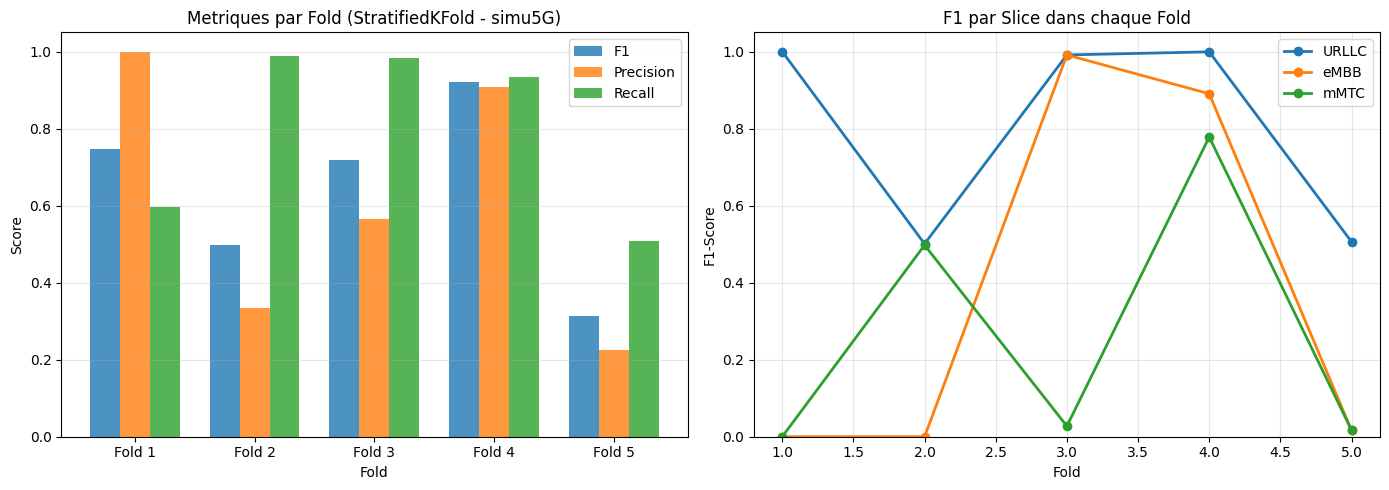


Conclusion : Le modele est instable (std F1 = 0.2361)


In [30]:
# Visualisation des resultats de la cross-validation
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Metriques par fold
metrics = ['f1', 'precision', 'recall']
x = np.arange(len(cv_df))
width = 0.25

for i, metric in enumerate(metrics):
    axes[0].bar(x + i * width, cv_df[metric], width, label=metric.capitalize(), alpha=0.8)

axes[0].set_xlabel('Fold')
axes[0].set_ylabel('Score')
axes[0].set_title('Metriques par Fold (StratifiedKFold - simu5G)')
axes[0].set_xticks(x + width)
axes[0].set_xticklabels([f'Fold {i+1}' for i in range(len(cv_df))])
axes[0].legend()
axes[0].grid(True, alpha=0.3, axis='y')
axes[0].set_ylim(0, 1.05)

# F1 par slice dans chaque fold
slice_cols = [c for c in cv_df.columns if c.startswith('f1_')]
for col in slice_cols:
    st = col.replace('f1_', '')
    axes[1].plot(cv_df['fold'], cv_df[col], 'o-', label=st, linewidth=2, markersize=6)

axes[1].set_xlabel('Fold')
axes[1].set_ylabel('F1-Score')
axes[1].set_title('F1 par Slice dans chaque Fold')
axes[1].legend()
axes[1].grid(True, alpha=0.3)
axes[1].set_ylim(0, 1.05)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'cross_validation_results_simu5g.png'), dpi=150)
plt.show()

print(f'\nConclusion : Le modele est {"stable" if cv_df["f1"].std() < 0.1 else "instable"} '
      f'(std F1 = {cv_df["f1"].std():.4f})')

## 8. Analyse et sauvegarde

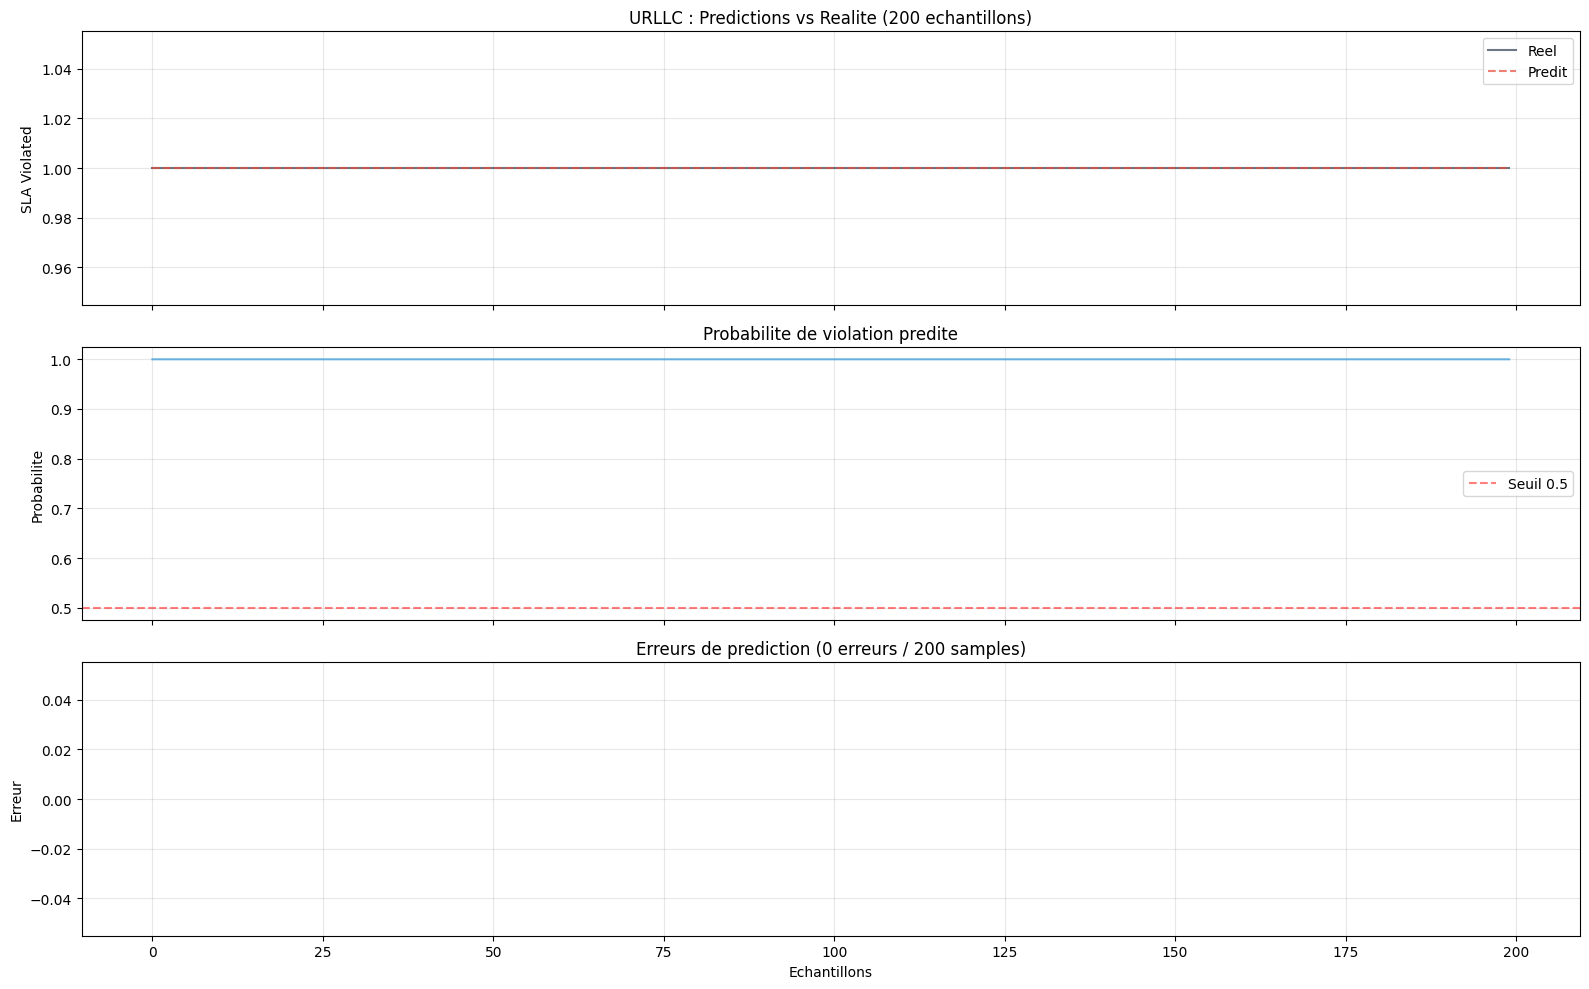

In [31]:
# --- Analyse temporelle des predictions sur URLLC ---
# URLLC est le slice avec le plus de violations (45.8%)
urllc_mask = sl_test == 'URLLC'
if urllc_mask.sum() > 200:
    window = slice(0, 200)
    fig, axes = plt.subplots(3, 1, figsize=(16, 10), sharex=True)

    axes[0].plot(y_test[urllc_mask][window], label='Reel', color='#2c3e50', alpha=0.7)
    axes[0].plot(y_pred[urllc_mask][window], label='Predit', color='#e74c3c', alpha=0.7, linestyle='--')
    axes[0].set_ylabel('SLA Violated')
    axes[0].set_title('URLLC : Predictions vs Realite (200 echantillons)')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)

    axes[1].plot(y_pred_proba[urllc_mask][window], color='#3498db', alpha=0.7)
    axes[1].axhline(y=0.5, color='red', linestyle='--', alpha=0.5, label='Seuil 0.5')
    axes[1].set_ylabel('Probabilite')
    axes[1].set_title('Probabilite de violation predite')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)

    # Erreurs
    errors = np.abs(y_test[urllc_mask][window] - y_pred[urllc_mask][window])
    axes[2].bar(range(len(errors)), errors, color='#e74c3c', alpha=0.5)
    axes[2].set_ylabel('Erreur')
    axes[2].set_xlabel('Echantillons')
    axes[2].set_title(f'Erreurs de prediction ({errors.sum():.0f} erreurs / {len(errors)} samples)')
    axes[2].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig(os.path.join(OUTPUT_DIR, 'urllc_temporal_analysis_simu5g.png'), dpi=150)
    plt.show()

In [32]:
# --- Sauvegarde du modele PyTorch ---
model_path = os.path.join(OUTPUT_DIR, 'lstm_approach_b_simu5g.pt')
torch.save({
    'model_state_dict': model.state_dict(),
    'n_features': n_features,
    'lookback': LOOKBACK,
    'history': history,
}, model_path)
print(f'Modele sauvegarde : {model_path}')

# Sauvegarder le scaler pour inference future
import pickle
scaler_path = os.path.join(OUTPUT_DIR, 'scaler_approach_b_simu5g.pkl')
with open(scaler_path, 'wb') as f:
    pickle.dump(scaler, f)
print(f'Scaler sauvegarde : {scaler_path}')

# Resume final
print('\n' + '='*60)
print('RESUME - APPROCHE B (simu5G) - PyTorch LSTM')
print('='*60)
print(f'Dataset       : {len(df):,} lignes (13 scenarios)')
print(f'Features      : {n_features} (5 metriques + 15 derivees + 4 one-hot)')
print(f'Lookback      : {LOOKBACK}s')
print(f'Horizon       : 15s (labels originaux de l extraction)')
print(f'Split         : Leave-one-scenario-out (test sur scenarios jamais vus)')
print(f'Train samples : {len(X_train):,}')
print(f'Test samples  : {len(X_test):,}')
print(f'F1-score      : {f1_score(y_test, y_pred):.4f}')
print(f'AUC-ROC       : {roc_auc_score(y_test, y_pred_proba):.4f}')
print(f'Epochs        : {len(history["train_loss"])}')
print(f'Device        : {device}')

print('\n--- Resultats par slice ---')
for st, r in results_per_slice.items():
    print(f'  {st:14s} : F1={r["F1"]:.4f} | Prec={r["Precision"]:.4f} | Rec={r["Recall"]:.4f} | AUC={r["AUC"]:.4f}')

cv_f1_mean = cv_df['f1'].mean()
cv_f1_std = cv_df['f1'].std()
cv_auc_mean = cv_df['auc'].dropna().mean()

print(f'\n--- Cross-Validation (StratifiedKFold 5) ---')
print(f'  CV F1  = {cv_f1_mean:.4f} +/- {cv_f1_std:.4f}')
print(f'  CV AUC = {cv_auc_mean:.4f} +/- {cv_df["auc"].dropna().std():.4f}')

print('\n--- Comparaison avec Approche A (M/M/1) ---')
print('Approche A (M/M/1)        : F1=0.8606, AUC=0.9710, CV F1=0.8459+/-0.0356')
print(f'Approche B (simu5G LOSO)  : F1={f1_score(y_test, y_pred):.4f}, AUC={roc_auc_score(y_test, y_pred_proba):.4f}, CV F1={cv_f1_mean:.4f}+/-{cv_f1_std:.4f}')
print('='*60)

Modele sauvegarde : C:\Users\Utilisateur\Desktop\PFE_BigData\PFE_Bigdata\PFE-NetworkSlicing\PFE-NetworkSlicing\work\simu5g\output\lstm_approach_b_simu5g.pt
Scaler sauvegarde : C:\Users\Utilisateur\Desktop\PFE_BigData\PFE_Bigdata\PFE-NetworkSlicing\PFE-NetworkSlicing\work\simu5g\output\scaler_approach_b_simu5g.pkl

RESUME - APPROCHE B (simu5G) - PyTorch LSTM
Dataset       : 68,797 lignes (13 scenarios)
Features      : 23 (5 metriques + 15 derivees + 4 one-hot)
Lookback      : 30s
Horizon       : 15s (labels originaux de l extraction)
Split         : Leave-one-scenario-out (test sur scenarios jamais vus)
Train samples : 49,528
Test samples  : 18,099
F1-score      : 0.6479
AUC-ROC       : 0.9871
Epochs        : 9
Device        : cpu

--- Resultats par slice ---
  URLLC          : F1=0.9913 | Prec=0.9994 | Rec=0.9833 | AUC=0.9900
  eMBB           : F1=0.9913 | Prec=0.9994 | Rec=0.9833 | AUC=0.9903
  mMTC           : F1=0.0215 | Prec=0.0108 | Rec=1.0000 | AUC=0.3803

--- Cross-Validation (S